In [204]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt
import scipy as sci

In [205]:
# custom values
EDGE_LENGTH = 1e-3
ANGLE_OFFSET = np.pi/12
EDGE_OFFSET = 1e-5

DEFAULT_SIGMA = 1

# given paramters
RR = 0.06
BS = 0.004
RK = 0.02
SIGMA_1 = 1
SIGMA_2 = 10
SIMGA_3 = 0.05
SIGMA_4 = 20
DELTA_Z = 0.1

POTENTIAL_ANGLE = 10 * np.pi/180   # in rad

POTENTIAL_1 = 1     # V
POTENTIAL_2 = -1    # V

In [206]:
# points on the inner circle
angle_5 = np.arccos(0.5*BS / RK)
height_5 = np.sin(angle_5) * RK

# points on the outer circle
angle_6 = np.arccos(0.5*BS / RR)
height_6 = np.sin(angle_6) * RR
angle_13 = np.pi - angle_6
angle_17 = angle_6 + np.pi
angle_3 = angle_13 + np.pi  # oder # angle_3 = -np.pi + angle_6

# potential parts on the outer circle
angle_11 = np.pi - 0.25*np.pi - 0.5*POTENTIAL_ANGLE
angle_12 = angle_11 + 0.5*POTENTIAL_ANGLE
angle_9 = angle_11 + np.pi
# angle_10 = 0 - 0.25*np.pi + 0.5*POTENTIAL_ANGLE
angle_10 = angle_12 + np.pi

In [207]:
def get_xy_from_angle(angle, radius):
    y = np.sin(angle) * radius 
    x = np.cos(angle) * radius
    return x,y

x_p9, y_p9 = get_xy_from_angle(angle_9, RR)
x_p11, y_p11 = -x_p9, -y_p9

x_p10, y_p10 = get_xy_from_angle(angle_10, RR)
x_p12, y_p12 = -x_p10, -y_p10

x_p6, y_p6 = get_xy_from_angle(angle_6, RR)
x_p13, y_p13 = -x_p6, y_p6

x_p3, y_p3= x_p6, -y_p6
x_p17, y_p17 = x_p13, -y_p13

x_p5, y_p5 = get_xy_from_angle(angle_5, RR)
x_p4, y_p4 = x_p5, -y_p5

x_p14, y_p14 = -x_p5, y_p5
x_p16, y_p16 = x_p14, -y_p14

In [208]:
# def _get_permability(x,y):
#     epsilpon_r = 1
    
#     return sci.constants.epslion_0 * epsilpon_r

def get_radius(x,y):
    return np.sqrt( np.power(x, 2) + np.power(y, 2) )

def get_sigma(x, y):

    if get_radius(x,y) <= RK:
        if y > 0:
            sigma = SIMGA_3
            # plt.scatter(x,y, color="green")
        else:
            sigma = SIGMA_4
            # plt.scatter(x,y, color="white")
    elif np.abs(x) <=0.5*BS:
        if y >= 0:
            sigma = SIMGA_3
            # plt.scatter(x,y, color="green")
        else:
            sigma = SIGMA_4
            # plt.scatter(x,y, color="white")
    elif x > 0:
        sigma =  SIGMA_2
        # plt.scatter(x,y, color="blue")
    else:
        sigma = SIGMA_1
        # plt.scatter(x,y, color="red")
    
    return sigma

def alpha1(x, y):
    return 1/get_sigma(x,y)

def alpha2(x, y):
    return alpha1(x, y)

def beta(x, y):
    return 0

def rhs(x, y):
    return 0

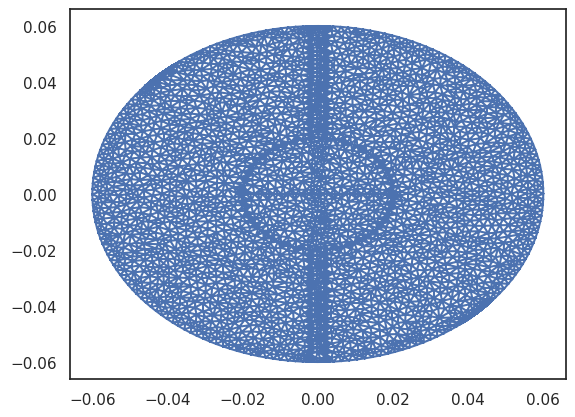

In [209]:
nodes, elements, boundary_edge, boundary_inidces, boundary_elements, outer_curve, inner_curve = mt.LoadTriMesh("Netz_SS25.npz", show=True)

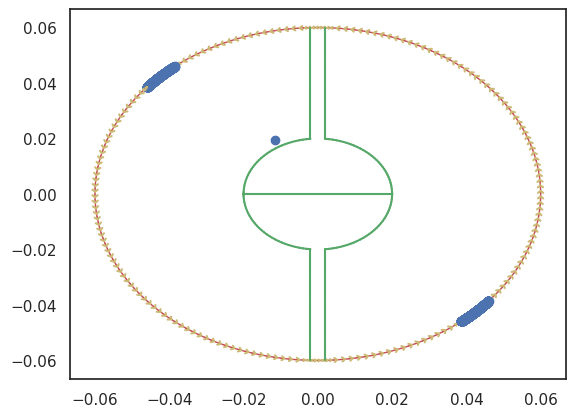

In [210]:
# Vordefinierte Punkte
dalpha=10
angles=np.array([-90, -45-dalpha/2, -45+dalpha/2, 135-dalpha/2, 135+dalpha/2, 270])*np.pi/180
P3 = [ BS/2 , -np.sqrt(RR**2-(BS/2)**2) ]  #
P4 = [ BS/2 , -np.sqrt(RK**2-(BS/2)**2) ]
P5 = [ BS/2 ,  np.sqrt(RK**2-(BS/2)**2) ]
P6 = [ BS/2 , np.sqrt(RR**2-(BS/2)**2) ]    #
an = np.arctan(2*P5[1]/BS)
P9 = [RR*np.cos(angles[1]),RR*np.sin(angles[1])]
P10 = [RR*np.cos(angles[2]),RR*np.sin(angles[2])]
P11 = [RR*np.cos(angles[3]),RR*np.sin(angles[3])]
P12 = [RR*np.cos(angles[4]),RR*np.sin(angles[4])]
P13= [ -P6[0], P6[1] ]
P14= [ -P5[0], P5[1] ]
P15= [ -RR, 0 ]
P16= [ -P4[0], P4[1] ]
P17= [ -P3[0], P3[1] ]

Ps=[P10,P11,P12,P9,P10]
Ps_types = ['Segments','Nodes','Segments','Nodes']
bseg=mt.RetrieveSegments(nodes,boundary_edge,boundary_inidces,Ps,Ps_types)

#Zeichne Ränder
for i in range(4):
  mt.PlotBoundary(nodes,bseg[i],Ps_types[i])
#Zeichne Innere Linien
mt.PlotBoundary(nodes,outer_curve,' ')
plt.plot(nodes[3291,0],nodes[3291,1],'o')
plt.show()

G0=bseg[1] +bseg[3]
G0=np.sort(G0)
R0=bseg[0]+bseg[2]

# DIRICHLET_INDICES = np.array(G0)

Ps=[P9,P10,P11,P12]
Ps_types = ['Segments','Segments','Segments']
bseg=mt.RetrieveSegments(nodes,boundary_edge,boundary_inidces,Ps,Ps_types)
ROBIN_INDICES = np.concatenate([bseg[0], bseg[2]])


Ps=[P10,P11,P12,P9]
Ps_types = ['Nodes','Nodes','Nodes']
bseg=mt.RetrieveSegments(nodes,boundary_edge,boundary_inidces,Ps,Ps_types)
DIRICHLET_INDICES = np.concatenate([bseg[0], bseg[2]])

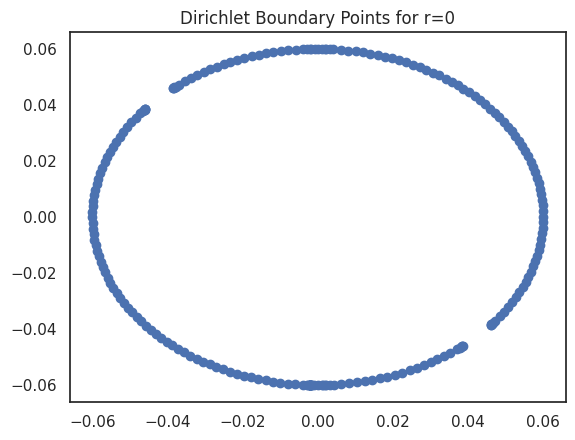

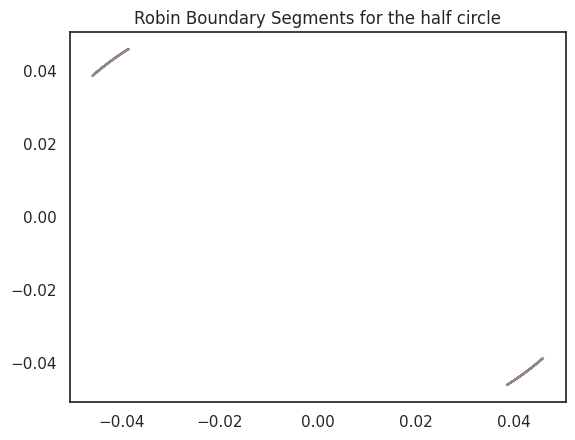

In [211]:
plt.scatter(nodes[DIRICHLET_INDICES][:,0], nodes[DIRICHLET_INDICES][:,1])

plt.title("Dirichlet Boundary Points for r=0")
plt.show()

fig, ax = plt.subplots()
for segment in nodes[ROBIN_INDICES]:
    x_val = [segment[0,0], segment[1,0]]
    y_val = [segment[0,1], segment[1,1]]

    ax.plot(x_val, y_val)

plt.title("Robin Boundary Segments for the half circle")
plt.show()

[np.float64(-0.03856725658119235), np.float64(0.04242640687119284)] [np.float64(0.045962666587138684), np.float64(-0.04242640687119286)]


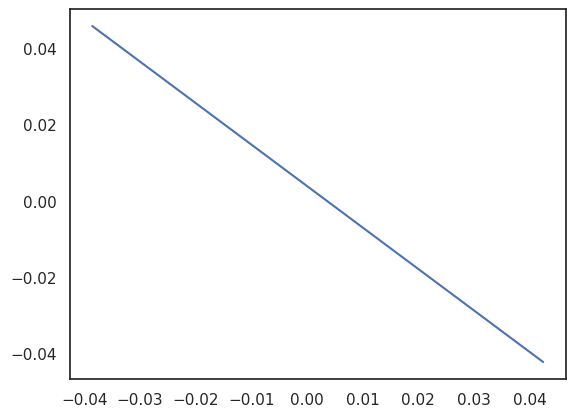

In [212]:
x= [x_p11, x_p10]
y= [y_p11, y_p10]
plt.plot(x,y)
print(x,y)

In [213]:
# def get_angle_from_xy(x,y):
#     angle = np.arctan2(y, x)

#     return angle

def dirichlet_func(x, y):

    if x > x_p11 and y > y_p10:
    # if (x_p11 <= x <= x_p10) and (y_p10 <= y <= y_p11):
        plt.scatter(x,y, color="red")
        return 0
    else:
        plt.scatter(x,y,color="green")
        return 1 / DELTA_Z


def robin_gamma(x, y):
    return 0  

def robin_rhs(x, y):
    return 0

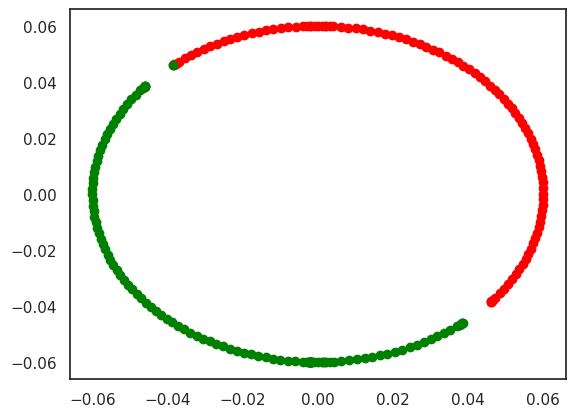

In [214]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(nodes, elements, alpha1, alpha2, beta, rhs)
stiffness_matrix, load_vector = myfunc.insert_robin_values(nodes, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)
stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(nodes, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet_func)

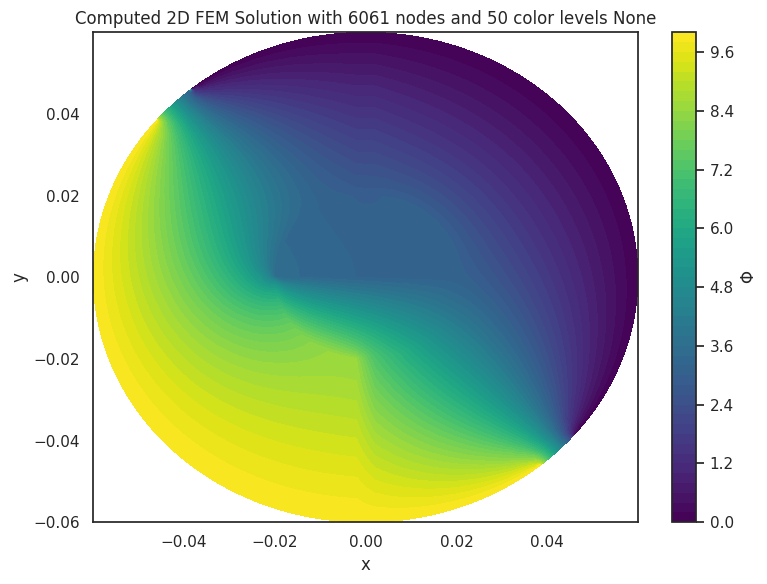

In [215]:
solution = myfunc.solve_system(nodes, stiffness_matrix, load_vector)
myfunc.plot_result(elements, solution, levels=50)

# fig, axis = plt.subplots(figsize=(8, 6))
# axis.set_xlim(0, 0.125)
# axis.set_ylim(-0.1, 0.1)
# myfunc.plot_result(elements, solution, levels=20, ax=axis, suffix="Zoomed")
# print(solution)

In [216]:
solution["Phi"][3291]

np.float64(3.213350637964276)